## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Abdul-Salam Gidado

**Date:** 10/1/26

### Q1 Answers

1. Regression is used to predict a continuous, numerical value, whereas classification is used to assign data to discrete, categorical labels.
2. A confusion table is a grid that compares the actual category labels of data points against the labels predicted by a model. It helps us see exactly which classes our model is predicting correctly and where it is making specific errors.
3. SSE measures the total squared difference between the actual numerical values and the values predicted by a model. It quantifies how far off, on average, the model's predictions are from the true data points.
4. Overfitting happens when a model learns the training data too perfectly, including its noise, making it perform poorly on new data. Underfitting happens when a model is too simple to capture the pattern in the data, resulting in poor performance on both training and new data.
5. Splitting the data ensures we evaluate the model on unseen data, which mimics real-world application. Finding the best k on a validation set helps us choose a model that generalizes well rather than one that just memorizes the training data.
6. Predicting a class label gives a direct, actionable answer, but hides how confident the model is in that choice. Providing a probability distribution shows the model's level of certainty for every possible class. It requires the user to decide on a decision threshold to take action.

### Q2 Part 1: Load and Explore the Data

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/land_mines.csv')

# Summarize target label and features
print("Dataset Summary")
print(df.info())
print("Feature Statistics")
print(df.describe())
print("Target Label Distribution")
print(df['mine_type'].value_counts())

Dataset Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
Feature Statistics
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
Target Label Distribution
mine_type
1    71
2    70
3    66
4    66
5    65
Nam

### Q2 Part 2: Split the Data 50/50

In [2]:
from sklearn.model_selection import train_test_split

X = df[['voltage', 'height', 'soil']]
y = df['mine_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (169, 3)
Testing set shape: (169, 3)


### Q2 Part 3: Build a $k$-NN Classifier

To find the best $k$, we test different values from 1 to 50 and calculate their error rates on both the training and validation sets. We choose the $k$ that gives the lowest error rate on the validation set to ensure our model generalizes well to new data.

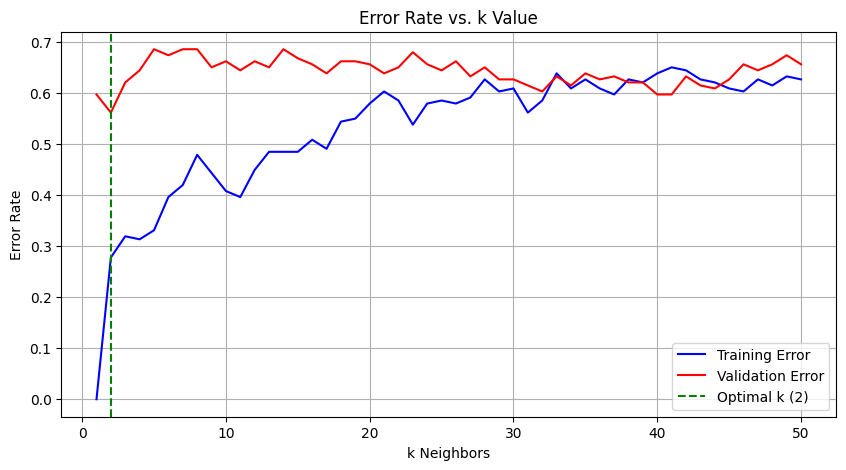

The optimal k is: 2. The best accuracy is 0.4379)


In [3]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


train_errors = []
val_errors = []
k_range = range(1, 51)

for k in k_range:
    # Fit k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_preds = knn.predict(X_train)
    val_preds = knn.predict(X_test)

    train_errors.append(1 - accuracy_score(y_train, train_preds))
    val_errors.append(1 - accuracy_score(y_test, val_preds))

# Find the k that minimizes validation error
optimal_k = k_range[np.argmin(val_errors)]
best_accuracy = 1 - min(val_errors)

# Plot the errors to visualize underfitting vs overfitting
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_errors, label='Training Error', color='blue')
plt.plot(k_range, val_errors, label='Validation Error', color='red')
plt.axvline(x=optimal_k, color='green', linestyle='--', label=f'Optimal k ({optimal_k})')
plt.title('Error Rate vs. k Value')
plt.xlabel('k Neighbors')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)
plt.show()

print(f"The optimal k is: {optimal_k}. The best accuracy is {best_accuracy:.4f})")

### Q2 Part 4: Confusion Table for the Optimal Model

In [4]:
from sklearn.metrics import confusion_matrix, classification_report

# Fit the optimal model
optimal_knn = KNeighborsClassifier(n_neighbors=optimal_k)
optimal_knn.fit(X_train, y_train)
final_preds = optimal_knn.predict(X_test)

# Make confusion matrix
cm = confusion_matrix(y_test, final_preds)
confusion_df = pd.DataFrame(cm,
                            index=[f'Actual {i}' for i in range(1, 6)],
                            columns=[f'Predicted {i}' for i in range(1, 6)])

print("Confusion Table")
print(confusion_df)

print("Classification Report")
print(classification_report(y_test, final_preds))

Confusion Table
          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           25            0            6            4            1
Actual 2            0           32            0            3            0
Actual 3           12            2            9            6            4
Actual 4           12            5            8            8            0
Actual 5           15            2           10            5            0
Classification Report
              precision    recall  f1-score   support

           1       0.39      0.69      0.50        36
           2       0.78      0.91      0.84        35
           3       0.27      0.27      0.27        33
           4       0.31      0.24      0.27        33
           5       0.00      0.00      0.00        32

    accuracy                           0.44       169
   macro avg       0.35      0.42      0.38       169
weighted avg       0.36      0.44      0.39       169



### Q2 Part 5: Practical Advice on Model Usage

In practice, some land mine mistakes are far more dangerous than others. I would advise mine operators to look at the predicted probability distribution instead of just trusting the final prediction. If the model is unsure or shows any chance of a high-risk mine type, they should treat the mine with extreme caution.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]